In [3]:
import torch
from docx import Document
import re
import faiss 
import sklearn.preprocessing as sp
import ollama
import json
from pydantic import BaseModel, Field
from typing import Optional,List
import requests

In [2]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
from sentence_transformers.training_args import BatchSamplers
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    losses
)
from transformers import EarlyStoppingCallback

In [4]:
kodap_new_txt = open('kodap_new_txt.txt','w',encoding = 'utf-8')
kodap = Document("kodap.docx")

for prgph in kodap.paragraphs:
    my_text = prgph.text.split('\n')
    for my_str in my_text:
        line = my_str.strip()
        if len(line) != 0:
            kodap_new_txt.write(line + '\n')

chanks = []
dict_elem = {'chapter_key': '',
             'chapter_title_key': '',
             'section_key': '',
             'section_title_key': '',
             'article_key':'',
             'article_title_key':'',
             'part_key':'',
             'text_key' : '' }
kodap_new_txt.close()

kodap_new_txt = open('kodap_new_txt.txt','r',encoding = 'utf-8')
chapter = ''
chapter_title = '' 
section = ''
section_title = '' 
article = '' 
article_title = '' 
part = '' 
text = ''
elem_values = [chapter,chapter_title,section,section_title,article,article_title,part,text]


for line in kodap_new_txt:
    line_new = line.split()
    word_first = line_new[0]
    len_word_first = len(word_first)
    flag = False
    if (word_first[0].isdigit()) and (word_first[len_word_first-1] != ')'):
        if ( chapter != '') and (section != '' ) and (article != '') and (text != ''):
            dict_elem['chapter_key'] = chapter
            dict_elem['chapter_title_key'] = chapter_title
            dict_elem['section_key'] = section
            dict_elem['section_title_key'] = section_title
            dict_elem['article_key'] = article
            dict_elem['article_title_key'] = article_title
            dict_elem['part_key'] = part
            dict_elem['text_key'] = ' '.join(text.replace('\n', ' ').split())
            chanks.append(dict_elem.copy())
        poisk4 = re.search(r"([\d]+\.)\s+(.+)",line)
        if poisk4 != None:
            part = poisk4.group(1)
            text = poisk4.group(2)
    elif (word_first == "Статья"):
        if ( chapter != '') and (section != '' ) and (article != '') and (text != ''):
            dict_elem['chapter_key'] = chapter
            dict_elem['chapter_title_key'] = chapter_title
            dict_elem['section_key'] = section
            dict_elem['section_title_key'] = section_title
            dict_elem['article_key'] = article
            dict_elem['article_title_key'] = article_title
            dict_elem['part_key'] = part
            dict_elem['text_key'] = ' '.join(text.replace('\n', ' ').split())
            chanks.append(dict_elem.copy())
        text = ''
        part = '-'
        poisk3 = re.search(r"Статья\s+([\d\.\-]+)\s+(.+)", line)
        article = poisk3.group(1)
        article_title = poisk3.group(2)
    elif (word_first == "Глава"):
        text = ''
        part = '-'
        article = ''
        article_title =''
        flag = True
        poisk2 = re.search(r"Глава\s+([\d\.]+)\.\s+(.+)",line)
        section = poisk2.group(1)
        section_title = poisk2.group(2)
    elif (word_first == "Раздел"):
        text = ''
        part = '-'
        article = ''
        article_title =''
        section = ''
        section_title = ''
        poisk1 = re.search(r"Раздел\s+(V|IV|III|II|I)\.\s+(.+)",line)
        chapter = poisk1.group(1)
        chapter_title = poisk1.group(2)
    elif (line == ""):
        break
    else:
        text += line +'\n'
        
    
#print(len(chanks))
#for i in range (7,9):
#    print(chanks[i])
kodap_new_txt.close()

In [3]:
"""
Описание класса Data_Set
"""

In [5]:
class QuestionInformChunk(BaseModel):
    chapter_key: str
    chapter_title_key: str
    section_key: str
    section_title_key: str
    article_key: str
    article_title_key: str
    part_key: Optional[str] = None 
    text_key: str
    questions: List[str] = Field(default_factory=list)

#   model_config = ConfigDict(extra = 'ignore')
class DataSet(BaseModel):
    chunk: List[QuestionInformChunk] = Field(default_factory=list)

    def append_chunk(self, chunk_dict):
        self.chunk.append(QuestionInformChunk(**chunk_dict))
        
data_set = DataSet()  
for i in range (len(chanks)):
    data_set.append_chunk(chanks[i])
#print(data_set.chunk[0])

In [ ]:
#Generation _x2

In [6]:
def dict_prompts_generation():
    system_prompt = """
    Ты — эксперт в области российского административного права.
    Твоя специализация — Кодекс РФ об административных правонарушениях (КоАП РФ).
    Отвечай кратко и по делу. Не используй внутренние рассуждения и теги  / .
    """

    prompt_help_1 = """
    ОБЯЗАТЕЛЬНО:
    - Вопрос содержит номер статьи и части (если есть)
    - Вопрос о конкретном факте: что установлено, кто уполномочен, при каких условиях

    ЗАПРЕЩЕНО:
    - "эта статья", "этот закон", "настоящий закон"
    - "размер штрафа", "сумма", "проценты"
    - "какую роль", "какое значение"

    ВАЖНО: Человек, отвечая на вопрос, должен понять, к какой статье КоАП РФ относится ответ.

    ПРАВИЛЬНЫЕ ПРИМЕРЫ:
    Согласно статье 1.1 КоАП РФ, из каких компонентов состоит законодательство?
    Согласно статье 8.18 части 2 КоАП РФ, какие последствия наступают за самовольное изменение программы морских исследований?

    НЕПРАВИЛЬНЫЙ ПРИМЕР:
    Какие последствия наступают по данной статье?
    Кто является субъектом правонарушения по указанной статье?  
    """

    prompt_help_2 = """
    ОБЯЗАТЕЛЬНО:
    - Каждый вопрос о РАЗНОМ факте из текста
    - Вопрос должен содержать ключевые слова из текста, чтобы человек понял, о какой статье идет речь
    - Вопросы не должны повторять первый вопрос и друг друга

    ЗАПРЕЩЕНО:
    - Указывать номер статьи, часть или КоАП РФ
    - "какую роль", "какое значение"
    - Слова: "статья", "по статье", "согласно статье", "в соответствии со статьей", "данная статья", "эта статья", "настоящий закон", "настоящий Кодекс", "по данной норме"

    ВАЖНО: Человек, отвечая на вопросы, должен понять, к какой статье КоАП РФ относится ответ.

    ПРАВИЛЬНЫЙ ПРИМЕР:
    На каком основании назначается административный штраф в размере пяти тысяч рублей при отсутствии в санкции статьи административного наказания в виде штрафа?  
    Какие органы исполнительной власти субъектов РФ участвуют в рассмотрении дел?
    Какие источники могут определять минимальный размер штрафа для должностных лиц?

    НЕПРАВИЛЬНЫЙ ПРИМЕР:
    Согласно статье 1.1 КоАП РФ, из каких компонентов состоит законодательство?
    Какие транспортные средства подлежат ответственности по данной норме?
    Какие параметры регулируются нормативами, указанными в статье?По вопросам надо будет позже достоверно определить статью 
    """
    dict_prompt = {'system_prompt': system_prompt,
                  'prompt_help_1': prompt_help_1,
                  'prompt_help_2': prompt_help_2}
    
    return dict_prompt
    
def prompt_quantion(i,data_set):
    chunk = data_set.chunk[i]
    text = (
        "Твоя задача — по тексту статьи КоАП РФ сгенерировать 1 уникальный вопрос по правилам,в котором ОБЯЗАТЕЛЬНО и БУКВАЛЬНО будет использован этот номер статьи и части(если есть)"
        f"Статья: {chunk.text_key}, номер статьи {chunk.article_key},"
    )
    if chunk.part_key:
        text += f"часть {chunk.part_key}"
    return text
    
def generation_data_set(file_name,data_set):
    need_prompts = dict_prompts_generation()
    system_prompt = need_prompts['system_prompt']
    prompt_help_1 = need_prompts['prompt_help_1']
    prompt_help_2 = need_prompts['prompt_help_2']

    len_data_set = len(data_set.chunk)    
    
    with open(file_name, "a", encoding="utf-8") as f:
        for i in range(0,len_data_set):
            first_question = None
            max_retries = 5
            for attempt in range(max_retries):
                my_prompt = prompt_quantion(i,data_set) + prompt_help_1
                res = ollama.generate(
                    model='qwen3:8b',
                    system=system_prompt,
                    prompt=my_prompt,
                    options={"temperature": 0.35, "no_think": True}
                )
                parsed = res['response'].strip()
            
                for quest in parsed.splitlines():
                    if quest.strip():
                        first_question = quest.strip()
                        break
            
                if first_question:
                    break
                else:
                    print(f"Чанк {i}: попытка {attempt+1} не дала вопроса, повторяем...")
        
            data_set.chunk[i].questions.append(first_question)
            f.write(f"chunk {i}\n")
            f.write(first_question + "\n")
        
            prompt_quantion_2 = (
                " Твоя задача — по тексту статьи КоАП РФ сгенерировать 3 уникальных вопроса по правилам. "
                f"Статья: {data_set.chunk[i].text_key}, не дублируй и не повторяй этот вопрос {data_set.chunk[i].questions[0]}"
            )
            my_prompt2 = prompt_quantion_2 + prompt_help_2
            res2 = ollama.generate(
                model='qwen3:8b',
                system=system_prompt,
                prompt=my_prompt2,
                options={"temperature": 0.35, "no_think": True}
            )
            parsed2 = res2['response']
            for quest in parsed2.splitlines():
                data_set.chunk[i].questions.append(quest.strip())
                f.write(quest + "\n")
            f.flush()

In [15]:
"""
Генерация data_set
"""

'\nГенерация data_set\n'

In [1]:
generation_data_set("question_new_3.0_.txt", data_set)

NameError: name 'generation_data_set' is not defined

In [ ]:
#Generation-1
#25,len(data_set.chunk)

In [17]:
def dict_promts_rate():
    prompt_help_2_gen = """
    Сгенерируй один вопрос по тексту статьи КоАП РФ БЕЗ упоминания её номера.
    ОБЯЗАТЕЛЬНО:
    - Вопрос должен быть о КОНКРЕТНОМ факте, термине или условии.
    - Используй УНИКАЛЬНЫЕ слова, цифры или термины из текста, чтобы по вопросу можно было найти эту статью (но не называй саму статью).
    - Не используй фразы "по статье", "согласно закона".

    ЗАПРЕЩЕНО:
    - Указывать номер статьи, части или слова "КоАП", "Кодекс".
    - Общие вопросы.

    Верни ТОЛЬКО текст вопроса.
    """
    promt_system_new = "Ты — эксперт по оценке качества обучающих данных для юридических LLM, который четко выполняет инструкции и следует правилам, не добавляет никаких пояснений."
    
    system_prompt_gen = """Ты — генератор учебных вопросов. 
    Твоя единственная задача — сгенерировать ВОПРОС.
    Ты НЕ даёшь ответы. Ты НЕ пишешь утверждения.
    Ты возвращаешь ТОЛЬКО вопросительное предложение, заканчивающееся на "?".
    """
    prompt_help_1_new = """
    Твоя задача оценить вещественным числом качество вопроса от 0 до 1.
    Никаких пояснений, никаких дополнительных слов.

    ШАГ 1. ОЦЕНКА КАЧЕСТВА (от 0.0 до 1.0)
    Используй критерии в зависимости от флага, определенного в Шаге 1:

    Критерии оценки (0.0 - 1.0):
    1. Фактическая точность: Ответ на вопрос содержится в тексте статьи.
    2. Конкретность: Вопрос требует конкретного факта, определения или условия, а не абстрактного рассуждения ("какую роль", "значение").
    3. Уникальность: Вопрос не повторяет смысл других вопросов.
    4. Однозначность (Идентифицируемость): В вопросе обязательно должны быть уникальные слова, термины или цифры из текста, отличающие эту статью от других. Если уникальных слов нет — снижай оценку.

    Оцени по шкале 0-1, где:
    - 0.0 - 0.4: Плохой. Ответа нет в тексте, вопрос абстрактный или некорректный.
    - 0.5 - 0.6: Слабый. Ответ есть, но вопрос слишком общий, или есть дубликат.
    - 0.7 - 0.8: Хороший. Конкретный вопрос, ответ есть в тексте.
    - 0.9 - 1.0: Идеальный. Четкий, уникальный, проверяет важный нюанс.

    Даже если знаешь номер статьи — НЕ ПИШИ ЕГО.

    Если вопрос будет содержать "статья 1.1" или "КоАП РФ" — это ОШИБКА.

    Примеры:
    Вопрос:
    Какие источники могут устанавливать особые условия для применения мер обеспечения производства по делу с должностными лицами, выполняющими государственные функции?  
    Вывод:
    1.0

    Вопрос:
    Какие объекты недвижимости включаются в круг владельцев согласно статье?
    Вывод:
    0.3
    ---
    ТЕПЕРЬ ОЦЕНИ СЛЕДУЮЩИЙ ВОПРОС:
    """

    dict_promts = {'prompt_help_2_gen': prompt_help_2_gen,
                   'promt_system_new': promt_system_new,
                   'system_prompt_gen': system_prompt_gen,
                   'prompt_help_1_new':prompt_help_1_new
    }
    return dict_promts

def rating_question(data_set, inform, number_chunk, number_str_chunk, number_str_question, promt_system_new, prompt_help_1_new, new_question=""):
    if new_question == "":
        prompt_help_3_new = f"ТЕКСТ СТАТЬИ ДЛЯ КОНТЕКСТА\n{data_set.chunk[number_chunk].text_key}\n\nТЕКСТ ВОПРОСА НА АНАЛИЗ:\n{inform[number_str_question]}\n"
        check = inform[number_str_question]
    else:
        prompt_help_3_new = f"ТЕКСТ СТАТЬИ ДЛЯ КОНТЕКСТА\n{data_set.chunk[number_chunk].text_key}\n\nТЕКСТ ВОПРОСА НА АНАЛИЗ:\n{new_question}\n"
        check = new_question
    
    prompt_help_4_new = ""
    for j in range(number_str_chunk + 1, min(len(inform), number_str_chunk + 5)):
        if inform[j] != check:
            prompt_help_4_new += inform[j] + ','
    prompt_help_4_new = prompt_help_4_new.rstrip(', ')
    
    my_prompt2_new = (prompt_help_1_new + "\n\n" + prompt_help_3_new + 
                      "\n\nДРУГИЕ ВОПРОСЫ К ЭТОЙ СТАТЬЕ (для проверки уникальности)\n\n" + prompt_help_4_new)
    
    res = ollama.chat(model='qwen3:8b', messages=[
        {'role': 'system', 'content': promt_system_new},
        {'role': 'user', 'content': my_prompt2_new}
    ], options={"temperature": 0.0,"seed": 42 },keep_alive='30h')
    
    parsed = res['message']['content']
    if isinstance(parsed, (list, tuple)):
        parsed = parsed[0] 
    return parsed


def generate_question(data_set,inform,number_str_question,number_chunk,number_str_chunk,system_prompt,prompt_help_2):
    questions = []
    for j in range (number_str_chunk+1,min(len(inform), number_str_chunk + 5)): 
        if inform[j] != inform[number_str_question]:
            questions.append(inform[j])
    str_chunk = "Избегай тем и формулировок, используемых в этих вопросах: " + "; ".join(questions)
    prompt_quantion_2 = f"Статья: {data_set.chunk[number_chunk].text_key}" + str_chunk
    my_prompt = prompt_quantion_2 + prompt_help_2
    res2 = ollama.generate(
            model='qwen3:8b',
            system=system_prompt,
            prompt=my_prompt,
            options={"temperature": 0.35, "no_think": True,'num_predict': 1000})
    parsed = res2['response']
    return parsed
                        
def safe_rating_question(data_set, inform, number_chunk, number_str_chunk, number_str_question, promt_system_new, prompt_help_1_new, new_question="", max_retries=3):
    for attempt in range(max_retries):
        try:
            result = rating_question(data_set, inform, number_chunk, number_str_chunk,number_str_question, promt_system_new, prompt_help_1_new,new_question)
            match = re.search(r'([0-1](?:\.[0-9]+)?)', str(result))
            if match:
                score = match.group(1)
                return score
        except Exception as e:
            print(f" Ошибка: {e}")
        
    print(f"Возвращаю 0.0 после {max_retries} попыток")
    return "0.0"

def last_chunk(file_name):
    with open(file_name,"r",encoding = 'utf-8') as f:
        inform = f.readlines()
        number_chunk = None
        number_str_chunk = -1
        for i in range(len(inform)):
                    inform[i] = inform[i].rstrip('\n ')
        for i in range (0,len(inform)): 
             if inform[i].find('chunk') == 0:
                 if (i > number_str_chunk):
                     number_str_chunk = i
                     number_chunk = int(inform[i].split()[1])
    return number_chunk

def rate_data_set(file_name,file_name_rate,file_name_patches, data_set):
    need_promts = dict_promts_rate()
    prompt_help_2_gen = need_promts['prompt_help_2_gen']
    promt_system_new =  need_promts['promt_system_new']
    system_prompt_gen = need_promts['system_prompt_gen']
    prompt_help_1_new = need_promts['prompt_help_1_new']


    number_last_chunk = last_chunk(file_name)
    with open(file_name, "r", encoding="utf-8") as f:
        with open(file_name_rate, "a", encoding="utf-8") as f_2:
            inform = f.readlines()
            for i in range(len(inform)):
                inform[i] = inform[i].rstrip('\n ')
            i = 0
            while i < len(inform):
                if inform[i].find('chunk') == 0:
                    number_str_chunk = i
                    number_chunk = int(inform[i].split()[1])
                    f_2.write(f'chunk {number_chunk}\n')
                    f_2.flush()
                    match = False
                    try:
                        for j in range (i+1,i+5):
                            match = re.search(r"chunk",inform[j])
                            if match:
                                i = j
                                f_2.write('Структура нарушена(короче необходимой)\n')
                                break
                    except IndexError:
                        f_2.write('Структура нарушена (короче необходимой - конец файла)\n')
                        i = len(inform)
                        continue
                    if match:
                        continue
                    flag = True
                    for j in range (i+1,min(len(inform),i+5)):
                        if "?" not in inform[j]:
                            flag = False
                            f_2.write('Структура нарушена (нет вопросов)\n')
                            break
                    if flag == False:
                        for j in range (i+5,len(inform)):
                            match = re.search(r"chunk",inform[j])
                            if match:
                                i = j
                                break
                        else:
                            i = len(inform)
                        continue
                    if (flag == True) and ((number_chunk == number_last_chunk) or (re.search(r"chunk",inform[i + 5]))):
                        f_2.write('rate: 1.0\n')
                        for j in range (2,5):
                            index_question = number_str_chunk + j
                            output_func = safe_rating_question(data_set,inform,number_chunk,number_str_chunk,index_question,promt_system_new,prompt_help_1_new)
                            rate = output_func
                            if float(rate) < 0.7:
                                attemption = 0
                                while (attemption < 3): 
                                    new_question = generate_question(data_set,inform,index_question,number_chunk,number_str_chunk,system_prompt_gen,prompt_help_2_gen)
                                    output_func= safe_rating_question(data_set,inform,number_chunk,number_str_chunk,index_question,promt_system_new,prompt_help_1_new,new_question)
                                    rate = output_func
                                    attemption += 1
                                    if float(rate) >= 0.7:
                                        inform[index_question] = new_question
                                        with open(file_name_patches, "a", encoding="utf-8") as patch:
                                            patch.write(f"{index_question}| {new_question}\n")
                                        f_2.write(f'rate: {rate}\n')
                                        f_2.flush()
                                        break
                                else:
                                    f_2.write(f'Не удалось сгенерировать хороший вопрос после 3 попыток\n')
                                    f_2.flush()
                            
                            else:
                                f_2.write(f'rate: {rate}\n')
                                f_2.flush()
                        i += 5
                    else:
                        for j in range (i+5,len(inform)):
                            match = re.search(r"chunk",inform[j])
                            if match:
                                i = j
                                f_2.write('Структура нарушена (длиннее необходимой)\n')
                                break
                        else:
                            i = len(inform)
#Все параметры и вся индексаиця в файле идут относительно индексации массива

In [9]:
"""
Оценка рейтинга чанков
"""

In [ ]:
rate_data_set('question_new_3.0.txt','question_new_3.0_rate.txt','patches.txt',data_set)

In [ ]:
"Обработка полученных чанков"

In [39]:
def processing_rate(file_name_rate):
    array_number_chunk = []
    with open (file_name_rate,"r", encoding = 'utf-8') as f:
        inform = f.readlines()
        for i in range(len(inform)):
            poisk = re.search(r"Структура нарушена", inform[i])
            if poisk:
                poisk_number = re.search(r"\d+",inform[i-1])
                array_number_chunk.append(poisk_number.group())
    return array_number_chunk

In [ ]:
"Перегенерация проблемных чанков"

In [64]:
def dict_promts_generation():
    system_prompt = """
    Ты — эксперт в области российского административного права.
    Твоя специализация — Кодекс РФ об административных правонарушениях (КоАП РФ).
    Отвечай кратко и по делу. Не используй внутренние рассуждения и теги  / .
    """

    prompt_help_1 = """
    ОБЯЗАТЕЛЬНО:
    - Вопрос содержит номер статьи и части (если есть)
    - Вопрос о конкретном факте: что установлено, кто уполномочен, при каких условиях

    ЗАПРЕЩЕНО:
    - "эта статья", "этот закон", "настоящий закон"
    - "размер штрафа", "сумма", "проценты"
    - "какую роль", "какое значение"

    ВАЖНО: Человек, отвечая на вопрос, должен понять, к какой статье КоАП РФ относится ответ.

    ПРАВИЛЬНЫЕ ПРИМЕРЫ:
    Согласно статье 1.1 КоАП РФ, из каких компонентов состоит законодательство?
    Согласно статье 8.18 части 2 КоАП РФ, какие последствия наступают за самовольное изменение программы морских исследований?

    НЕПРАВИЛЬНЫЙ ПРИМЕР:
    Какие последствия наступают по данной статье?
    Кто является субъектом правонарушения по указанной статье?  
    """

    prompt_help_2 = """
    ОБЯЗАТЕЛЬНО:
    - Каждый вопрос о РАЗНОМ факте из текста
    - Вопрос должен содержать ключевые слова из текста, чтобы человек понял, о какой статье идет речь
    - Вопросы не должны повторять первый вопрос и друг друга

    ЗАПРЕЩЕНО:
    - Указывать номер статьи, часть или КоАП РФ
    - "какую роль", "какое значение"
    - Слова: "статья", "по статье", "согласно статье", "в соответствии со статьей", "данная статья", "эта статья", "настоящий закон", "настоящий Кодекс", "по данной норме"

    ВАЖНО: Человек, отвечая на вопросы, должен понять, к какой статье КоАП РФ относится ответ.

    ПРАВИЛЬНЫЙ ПРИМЕР:
    На каком основании назначается административный штраф в размере пяти тысяч рублей при отсутствии в санкции статьи административного наказания в виде штрафа?  
    Какие органы исполнительной власти субъектов РФ участвуют в рассмотрении дел?
    Какие источники могут определять минимальный размер штрафа для должностных лиц?

    НЕПРАВИЛЬНЫЙ ПРИМЕР:
    Согласно статье 1.1 КоАП РФ, из каких компонентов состоит законодательство?
    Какие транспортные средства подлежат ответственности по данной норме?
    Какие параметры регулируются нормативами, указанными в статье?По вопросам надо будет позже достоверно определить статью 
    """
    dict_promt = {'system_prompt': system_prompt,
                  'prompt_help_1': prompt_help_1,
                  'prompt_help_2': prompt_help_2}
    
    return dict_promt
def regeneration_of_problematic_chunks(file_name,file_name_rate,data_set):
    need_promts = dict_promts_generation()
    system_prompt = need_promts['system_prompt']
    prompt_help_1 = need_promts['prompt_help_1']
    prompt_help_2 = need_promts['prompt_help_2']
    
    array_number_chunk = processing_rate(file_name_rate)

    with open(file_name, "a", encoding="utf-8") as f:
        for j in array_number_chunk:
            i = int(j)
            first_question = None
            max_retries = 5
            for attempt in range(max_retries):
                my_prompt = prompt_quantion(i) + prompt_help_1
                res = ollama.generate(
                    model='qwen3:8b',
                    system=system_prompt,
                    prompt=my_prompt,
                    options={"temperature": 0.35, "no_think": True}
                )
                parsed = res['response'].strip()
            
                for quest in parsed.splitlines():
                    if quest.strip():
                        first_question = quest.strip()
                        break
            
                if first_question:
                    break
                else:
                    print(f"Чанк {i}: попытка {attempt+1} не дала вопроса, повторяем...")
        
            data_set.chunk[i].questions.append(first_question)
            f.write(f"chunk {i}\n")
            f.write(first_question + "\n")
        
            prompt_quantion_2 = (
                " Твоя задача — по тексту статьи КоАП РФ сгенерировать 3 уникальных вопроса по правилам. "
                f"Статья: {data_set.chunk[i].text_key}, не дублируй и не повторяй этот вопрос {data_set.chunk[i].questions[0]}"
            )
            my_prompt2 = prompt_quantion_2 + prompt_help_2
            res2 = ollama.generate(
                model='qwen3:8b',
                system=system_prompt,
                prompt=my_prompt2,
                options={"temperature": 0.35, "no_think": True}
            )
            parsed2 = res2['response']
            for quest in parsed2.splitlines():
                data_set.chunk[i].questions.append(quest.strip())
                f.write(quest + "\n")
            f.flush()

In [40]:
regeneration_of_problematic_chunks('question_new_3.0_update.txt','question_new_3.0_rate.txt',data_set)


KeyboardInterrupt



In [ ]:
"""
Повторные круги с оценкой,перегенерацией
"""

In [ ]:
"1 круг"

In [ ]:
rate_data_set('question_new_3.0_update.txt','question_new_3.0_update_rate.txt','patches_update.txt',data_set)

In [ ]:
regeneration_of_problematic_chunks('question_new_3.0_update_2_0.txt','question_new_3.0_update_rate.txt',data_set)

### 2 круг

In [55]:
rate_data_set('question_new_3.0_update_rate.txt','question_new_3.0_update_rate_2_0.txt','patches_update_2_0.txt',data_set)

In [65]:
regeneration_of_problematic_chunks('question_new_3.0_update_3_0.txt','question_new_3.0_update_rate_2_0.txt',data_set)

In [ ]:
"3 круг"

In [73]:
rate_data_set('question_new_3.0_update_3_0.txt','question_new_3.0_update_rate_3_0.txt','patches_update_3_0.txt',data_set)

Возвращаю 0.0 после 3 попыток
Возвращаю 0.0 после 3 попыток


In [ ]:
"""
Сборка правок единного data_set
"""

In [99]:
def patches_include_question(file_name_questions,file_name_patches):
    with open (file_name_patches,"r", encoding="utf-8") as f:
        inform = f.readlines()
        for i in range (len(inform)):
            inform[i] = inform[i].rstrip('\n')
        dict_patches = {}
        for i in range (len(inform)):
            if '|' in inform[i]:
                string = inform[i].split('|',1)
                index_string = int(string[0].strip())
                question = string[1].strip()
                if question:
                    dict_patches.update({index_string:question})
    index_string_patches = set(dict_patches.keys())
    with open(file_name_questions,"r", encoding="utf-8") as f2:
        inform_2 = f2.readlines()
        for i in range (len(inform_2)):
            if i in index_string_patches:
                inform_2[i] = dict_patches.get(i) + '\n'
    with open(file_name_questions,"w", encoding="utf-8") as f3:
        for line in inform_2:
            f3.write(line)

In [106]:
def question_chunk_update_include_questions(file_name_questions,file_name_questions_update,file_name_output):
    with open(file_name_questions_update,"r",encoding = 'utf-8') as f:
        inform = f.readlines()
        for i in range (len(inform)):
            inform[i] = inform[i].rstrip('\n')
        dict_update = {}
        i = 0
        while i < (len(inform)):
            if inform[i].find('chunk') == 0:
                array_question = []
                number_chunk = (inform[i].split())[1]
                for j in range(i+1,i+5):
                    array_question.append(inform[j] +'\n')
                dict_update.update({number_chunk: array_question})
                i += 5
    dict_patches_number = set(dict_update.keys())
    with open (file_name_questions,"r",encoding = 'utf-8') as f2:
        inform_2 = f2.readlines()
        for i in range (len(inform_2)):
            inform_2[i] = inform_2[i].rstrip('\n')
    with open (file_name_output,"w",encoding = 'utf-8') as f3:
        i = 0
        while i < len(inform_2):
            if inform_2[i].find('chunk') == 0:
                number_chunk = (inform_2[i].split())[1]
                if number_chunk not in dict_patches_number:
                    for j in range(i,i+5):
                        f3.write(inform_2[j] + '\n')
                else:
                    f3.write(f'chunk {number_chunk}\n')
                    array_question = dict_update.get(number_chunk)
                    for k in range (len(array_question)):
                        f3.write(array_question[k])
                i +=1
            else:
                i+=1

In [30]:
"""
Итоговая сборка готового файла с data_set
"""

In [101]:
patches_include_question('question_new_3.0_update_3_0.txt','patches_update_3_0.txt') 

In [102]:
patches_include_question('question_new_3.0_update_2_0.txt','patches_update_2_0.txt')

In [103]:
patches_include_question('question_new_3.0_update.txt','patches_update.txt')

In [104]:
patches_include_question('question_new_3.0.txt','patches.txt')

In [110]:
question_chunk_update_include_questions('question_new_3.0_update_2_0.txt','question_new_3.0_update_3_0.txt','questiom_include_1.txt')

In [111]:
question_chunk_update_include_questions('question_new_3.0_update.txt','questiom_include_1.txt','questiom_include_2.txt')

In [112]:
question_chunk_update_include_questions('question_new_3.0_copy.txt','questiom_include_2.txt','quesion_final.txt')

In [ ]:
"""
Создание train samples
"""

In [6]:
with open('quesion_final.txt', 'r', encoding='utf-8') as f2:
    inform = f2.readlines()
    for i in range (len(inform)):
        inform[i] = inform[i].strip()

with open('train_samples.jsonl','w',encoding='utf-8') as f:
    for i in range (len(data_set.chunk)):
        text_chunk = data_set.chunk[i].text_key
        article_number = data_set.chunk[i].article_key
        if (data_set.chunk[i].part_key != '-'):
            article_number =article_number + data_set.chunk[i].part_key
        for j in range(1,5):
            chunk_number = i * 5
            question = inform[chunk_number + j]
            sample = {
                      'article_key': article_number,
                      'anchor': question,
                      'positive' : text_chunk
                     }
            f.write(json.dumps(sample, ensure_ascii=False) + "\n")
            

In [7]:
data = []
with open("train_samples.jsonl",'r', encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

article_keys = set()
for i in range(len(data)):
    article_keys.add(data[i]['article_key'])

train_articles_number, test_articles_number = train_test_split(
    
    list(article_keys),
    test_size=0.2,
    random_state=42
)

In [8]:
set_test_articles_number = set(test_articles_number)

train_articles = []
test_articles = []

for i in range (len(data)):
    if data[i]['article_key'] in set_test_articles_number:
        test_articles.append(data[i])
    else:
        train_articles.append(data[i])

train_data_sample = []

for elem in train_articles:
    elem_array = {
            'anchor': elem['anchor'],
            'positive': elem['positive']
                 }
    train_data_sample.append(elem_array)

test_data_sample = []

for elem in test_articles:
    elem_array = {
            'anchor': elem['anchor'],
            'positive': elem['positive']
                 }
    test_data_sample.append(elem_array)

train_dataset = Dataset.from_list(train_data_sample)
test_dataset = Dataset.from_list(test_data_sample)

In [9]:
from sentence_transformers.evaluation import InformationRetrievalEvaluator 

queries = {} 
corpus = {} 
relevant_docs = {} 

for i, item in enumerate(data):
    if item['article_key'] in set_test_articles_number:

        article_id = item["article_key"]

        # corpus (документы)
        corpus[article_id] = item["anchor"]

        # queries (вопросы)
        q_id = f"q_{i}"
        queries[q_id] = item["positive"]

        # relevant_docs (ПРАВИЛЬНЫЕ ОТВЕТЫ)
        relevant_docs[q_id] = {article_id}

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    show_progress_bar=True,
    name="eval"
)

In [11]:
model = SentenceTransformer('intfloat/multilingual-e5-small')

train_loss = losses.MultipleNegativesRankingLoss(model)

args = SentenceTransformerTrainingArguments(
    output_dir=r"D:\Материалы для курсовой\Result_model_best",

    num_train_epochs=15,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    warmup_ratio=0.1,

    fp16=True, 

    batch_sampler=BatchSamplers.NO_DUPLICATES,

    gradient_accumulation_steps=4,

    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=5,
    
    load_best_model_at_end=True,            # загружаем лучшую версию
    metric_for_best_model="eval_cosine_accuracy@5",      # по этой метрики оцениваем лучшую
    greater_is_better=True,         # нам надо сохранить лучшую модель
    logging_dir=r"D:\Материалы для курсовой\logs_best",  # папка с логами
    report_to="tensorboard",                         # включить TensorBoard
    logging_steps=25,   
    

)

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    loss=train_loss,
    evaluator=evaluator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=7,     # 7 проверки без улучшения → стоп
            early_stopping_threshold=0.00001  # минимальное улучшение для сброса счетчика
        )
    ]
)

trainer.train(resume_from_checkpoint=False)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Cosine Accuracy@1,Cosine Accuracy@3,Cosine Accuracy@5,Cosine Accuracy@10,Cosine Precision@1,Cosine Precision@3,Cosine Precision@5,Cosine Precision@10,Cosine Recall@1,Cosine Recall@3,Cosine Recall@5,Cosine Recall@10,Cosine Ndcg@10,Cosine Mrr@10,Cosine Map@100
100,0.394000,No log,0.602917,0.750405,0.787682,0.844408,0.602917,0.250135,0.157536,0.084441,0.602917,0.750405,0.787682,0.844408,0.723590,0.684963,0.689723
200,0.140700,No log,0.625608,0.769854,0.810373,0.860616,0.625608,0.256618,0.162075,0.086062,0.625608,0.769854,0.810373,0.860616,0.745536,0.708582,0.712226
300,0.113600,No log,0.635332,0.769854,0.815235,0.863857,0.635332,0.256618,0.163047,0.086386,0.635332,0.769854,0.815235,0.863857,0.750725,0.714437,0.718132
400,0.097600,No log,0.636953,0.769854,0.821718,0.868720,0.636953,0.256618,0.164344,0.086872,0.636953,0.769854,0.821718,0.868720,0.754205,0.717458,0.721029
500,0.087100,No log,0.636953,0.773096,0.828201,0.880065,0.636953,0.257699,0.165640,0.088006,0.636953,0.773096,0.828201,0.880065,0.758704,0.719877,0.722899
600,0.106100,No log,0.646677,0.782820,0.829822,0.881686,0.646677,0.260940,0.165964,0.088169,0.646677,0.782820,0.829822,0.881686,0.764384,0.726842,0.729881
700,0.071900,No log,0.645057,0.776337,0.820097,0.881686,0.645057,0.258779,0.164019,0.088169,0.645057,0.776337,0.820097,0.881686,0.762319,0.724433,0.727738
800,0.049900,No log,0.638574,0.776337,0.823339,0.870340,0.638574,0.258779,0.164668,0.087034,0.638574,0.776337,0.823339,0.870340,0.756355,0.719666,0.723226
900,0.066100,No log,0.643436,0.787682,0.836305,0.884927,0.643436,0.262561,0.167261,0.088493,0.643436,0.787682,0.836305,0.884927,0.765093,0.726738,0.729472
1000,0.047700,No log,0.654781,0.794165,0.831442,0.880065,0.654781,0.264722,0.166288,0.088006,0.654781,0.794165,0.831442,0.880065,0.768181,0.732318,0.735519


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Corpus Chunks:   0%|                                                                                                                                                                                         | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Corpus Chunks:   0%|                                                                                                                                                                                         | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Corpus Chunks: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.06it/s]


TrainOutput(global_step=2200, training_loss=0.09419559523463249, metrics={'train_runtime': 897.7213, 'train_samples_per_second': 164.416, 'train_steps_per_second': 5.146, 'total_flos': 0.0, 'train_loss': 0.09419559523463249, 'epoch': 7.143089430894309})

In [ ]:
"""
tensorboard --logdir="D:\Материалы для курсовой\logs_model_2_2"
tensorboard --logdir="D:\Материалы для курсовой\logs_model_2"
tensorboard --logdir="D:\Материалы для курсовой\logs_2"
tensorboard --logdir="D:\Материалы для курсовой\logs"
"""

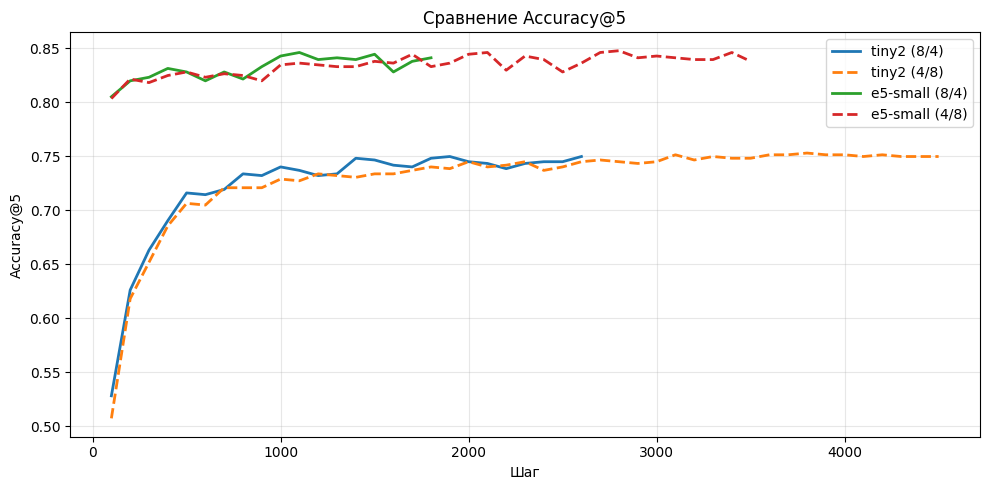

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "tiny2 (8/4)": r"D:\Материалы для курсовой\rubert-tiny (batch_8).csv",
    "tiny2 (4/8)": r"D:\Материалы для курсовой\rubert-tiny (batch_4).csv",
    "e5-small (8/4)": r"D:\Материалы для курсовой\multilingual-e5-small (batch 8).csv",
    "e5-small (4/8)": r"D:\Материалы для курсовой\multilingual-e5-small (batch 4).csv",
}

plt.figure(figsize=(10, 5))

for label, file in files.items():
    df = pd.read_csv(file)
    style = '-' if '8/4' in label else '--'
    plt.plot(df['Step'], df['Value'], label=label, linestyle=style, linewidth=2)

plt.xlabel('Шаг')
plt.ylabel('Accuracy@5')
plt.title('Сравнение Accuracy@5')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_all.png', dpi=200)
plt.show()

In [7]:
texts = []

best_model_after_study = SentenceTransformer(r"D:\Материалы для курсовой\Result_model_2_prepare\checkpoint-1800")
for chunk in chanks:
    texts.append(chunk['text_key'])
    
embeddings_database = best_model_after_study.encode(texts)  

embeddings_database_normilize = sp.normalize(embeddings_database,norm = 'l2',axis=1)
#CPU
#FAISS_base = faiss.IndexFlatIP(312)

#GPU 
res = faiss.StandardGpuResources()

memory = 1024 * 1024 * 50 #50 Мб размер базы 4.6

res.setTempMemory(memory)

config = faiss.GpuIndexFlatConfig()
config.device = 0
config.useFloat16 = False

FAISS_base = faiss.GpuIndexFlatIP(res,384,config)
FAISS_base.add(embeddings_database_normilize)


In [8]:
def question_to_article(question, model = best_model_after_study,FAISS_base = FAISS_base):
    question_vector = model.encode([question])
    question_vector = sp.normalize(question_vector, norm = 'l2', axis = 1)

    k = 5
    distances, indices = FAISS_base.search(question_vector, k)

    help_output = f"Запрос: {question}\n" 
    help_output_2 = "Топ 5 релевантных положений КоАП:"
    print(help_output + help_output_2)
    for i in range(k):
        index = int(indices[0][i])
        part_article =  chanks[index]['part_key']
        if part_article == '-':
            part_article = ""
        article = f"{chanks[index]['article_key']}{part_article} {chanks[index]['article_title_key']}\n {chanks[index]['text_key']}\n"
        similarity = f"Сходство: {distances[0][i]:.4f}\n"
        print(f"{i+1}: {article} {similarity}")

In [9]:
question = "Когда лицо считается невиновным в административном праве?"
question_to_article(question)

Запрос: Когда лицо считается невиновным в административном праве?
Топ 5 релевантных положений КоАП:
1: 1.5.2. Презумпция невиновности
 Лицо, в отношении которого ведется производство по делу об административном правонарушении, считается невиновным, пока его вина не будет доказана в порядке, предусмотренном настоящим Кодексом, и установлена вступившим в законную силу постановлением судьи, органа, должностного лица, рассмотревших дело.
 Сходство: 0.5487

2: 1.5.3. Презумпция невиновности
 Лицо, привлекаемое к административной ответственности, не обязано доказывать свою невиновность, за исключением случаев, предусмотренных примечанием к настоящей статье.
 Сходство: 0.5481

3: 1.5.1. Презумпция невиновности
 Лицо подлежит административной ответственности только за те административные правонарушения, в отношении которых установлена его вина.
 Сходство: 0.4295

4: 2.1.2. Административное правонарушение
 Юридическое лицо признается виновным в совершении административного правонарушения, если 